<a href="https://colab.research.google.com/github/imamshihbabaev/ml_projects_new/blob/main/Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/California_Fire_Incidents.csv')
df

,AcresBurned,Active,AdminUnit,AirTankers,ArchiveYear,CalFireIncident,CanonicalUrl,ConditionStatement,ControlStatement,Counties,...,SearchKeywords,Started,Status,StructuresDamaged,StructuresDestroyed,StructuresEvacuated,StructuresThreatened,UniqueId,Updated,WaterTenders
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,NaN,2013,True,/incidents/2013/8/17/rim-fire/,NaN,NaN,Tuolumne,...,"Rim Fire, Stanislaus National Forest, Yosemite...",2013-08-17T15:25:00Z,Finalized,NaN,NaN,NaN,NaN,5fb18d4d-213f-4d83-a179-daaf11939e78,2013-09-06T18:30:00Z,NaN
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,NaN,2013,True,/incidents/2013/5/30/powerhouse-fire/,NaN,NaN,Los Angeles,...,"Powerhouse Fire, May 2013, June 2013, Angeles ...",2013-05-30T15:28:00Z,Finalized,NaN,NaN,NaN,NaN,bf37805e-1cc2-4208-9972-753e47874c87,2013-06-08T18:30:00Z,NaN
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,NaN,2013,True,/incidents/2013/7/15/mountain-fire/,NaN,NaN,Riverside,...,"Mountain Fire, July 2013, Highway 243, Highway...",2013-07-15T13:43:00Z,Finalized,NaN,NaN,NaN,NaN,a3149fec-4d48-427c-8b2c-59e8b79d59db,2013-07-30T18:00:00Z,NaN
3,27440.0,False,Tahoe National Forest,NaN,2013,False,/incidents/2013/8/10/american-fire/,NaN,NaN,Placer,...,"American Fire, August 2013, Deadwood Ridge, Fo...",2013-08-10T16:30:00Z,Finalized,NaN,NaN,NaN,NaN,8213f5c7-34fa-403b-a4bc-da2ace6e6625,2013-08-30T08:00:00Z,NaN
4,24251.0,False,Ventura County Fire/CAL FIRE,NaN,2013,True,/incidents/2013/5/2/springs-fire/,Acreage has been reduced based upon more accur...,NaN,Ventura,...,"Springs Fire, May 2013, Highway 101, Camarillo...",2013-05-02T07:01:00Z,Finalized,6.0,10.0,NaN,NaN,46731fb8-3350-4920-bdf7-910ac0eb715c,2013-05-11T06:30:00Z,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1631,9.0,False,CAL FIRE / Riverside County Fire,NaN,2019,True,/incidents/2019/10/10/eagle-fire/,NaN,NaN,Riverside,...,NaN,2019-10-10T12:08:00Z,Finalized,NaN,NaN,NaN,NaN,6e93b252-99a3-4214-9921-238373b17535,2019-10-10T18:11:59.733Z,NaN
1632,2.0,False,CAL FIRE Nevada-Yuba-Placer Unit,NaN,2019,True,/incidents/2019/6/28/long-fire/,NaN,NaN,Nevada,...,NaN,2019-06-28T15:03:04Z,Finalized,NaN,NaN,NaN,NaN,b38c0563-b321-431b-9174-6336c5a0d449,2019-06-30T15:52:01.023Z,NaN
1633,NaN,False,Yolo County Fire Protection District,NaN,2019,False,/incidents/2019/11/25/cashe-fire/,NaN,NaN,Yolo,...,NaN,2019-11-25T12:02:02Z,Finalized,NaN,NaN,NaN,NaN,9c26f915-1b33-422d-b30a-9eb4da6fd729,2019-12-03T16:35:20.93Z,NaN
1634,NaN,False,Camp Pendleton Marine Corps Base,NaN,2019,False,/incidents/2019/10/22/oak-fire/,NaN,NaN,San Diego,...,NaN,2019-10-22T19:20:44Z,Finalized,NaN,NaN,NaN,NaN,7264a106-e0f4-41de-8fd0-3f9110431e28,2019-11-21T12:21:28.58Z,NaN


1.Датасет содержит информацию о лесных пожарах в Калифорнии.
Всего в наборе данных 1636 объектов и 40 признаков.
Часть признаков описывает географическое положение пожара, часть — ресурсы, задействованные при тушении, а также последствия пожара.

AcresBurned — площадь выгоревшей территории
AdminUnit — подразделение, ответственное за пожар
AirTankers, Helicopters, Dozers — техника, участвующая в тушении
Fatalities, Injuries — количество погибших и пострадавших
Latitude, Longitude — координаты
Started, Extinguished — даты начала и ликвидации пожара
PercentContained — процент локализации пожара

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AcresBurned           1633 non-null   float64
 1   Active                1636 non-null   bool   
 2   AdminUnit             1636 non-null   object 
 3   AirTankers            28 non-null     float64
 4   ArchiveYear           1636 non-null   int64  
 5   CalFireIncident       1636 non-null   bool   
 6   CanonicalUrl          1636 non-null   object 
 7   ConditionStatement    284 non-null    object 
 8   ControlStatement      105 non-null    object 
 9   Counties              1636 non-null   object 
 10  CountyIds             1636 non-null   object 
 11  CrewsInvolved         171 non-null    float64
 12  Dozers                123 non-null    float64
 13  Engines               191 non-null    float64
 14  Extinguished          1577 non-null   object 
 15  Fatalities           

2.найдем категориальные признаки и их количество


In [ ]:
categorials_columns=df.select_dtypes(include=['object']).columns
print("\n2. Категорильные признаки")
print("количество:", len(categorials_columns))
print(categorials_columns.tolist())


2. Категорильные признаки
количество: 16
['AdminUnit', 'CanonicalUrl', 'ConditionStatement', 'ControlStatement', 'Counties', 'CountyIds', 'Extinguished', 'FuelType', 'Location', 'Name', 'SearchDescription', 'SearchKeywords', 'Started', 'Status', 'UniqueId', 'Updated']


Категориальные признаки содержат текстовые значения и описывают различные характеристики пожаров: статус, округ, подразделение, URL инцидента и другие параметры.

3.столбцы с макимальным значением уникальных значений

In [ ]:
unique_counst=df[categorials_columns].nunique()

max_unique_col=unique_counst.idxmax()
max_unique_val=unique_counst.max()

print("\n3. Макисимум уникалных значений:")
print(max_unique_col, "->", max_unique_val)


3. Макисимум уникалных значений:
UniqueId -> 1609


Признак UniqueId практически уникален для каждого объекта и фактически является идентификатором записи.
Такие признаки обычно не несут полезной информации для машинного обучения и исключаются перед обучением модели, что и будем сделано дальше

4.бинарные признаки

In [ ]:
binary_cols = df.select_dtypes(include=['bool']).columns
print(binary_cols)

Index(['Active', 'CalFireIncident', 'Featured', 'Final', 'MajorIncident',
       'Public'],
      dtype='object')


бинарые признаки содержат только 2 возможных значения True/False

5.числовые признаки

In [ ]:
numeric_cols=df.select_dtypes(include=["int64","float64"]).columns
print("\n5. Числовые признаки:")
numeric_cols


5. Числовые признаки:


Index(['AcresBurned', 'AirTankers', 'ArchiveYear', 'CrewsInvolved', 'Dozers',
       'Engines', 'Fatalities', 'Helicopters', 'Injuries', 'Latitude',
       'Longitude', 'PercentContained', 'PersonnelInvolved',
       'StructuresDamaged', 'StructuresDestroyed', 'StructuresEvacuated',
       'StructuresThreatened', 'WaterTenders'],
      dtype='object')

Числовые признаки описывают количественные характеристики пожаров: площадь возгорания, количество техники, пострадавших, координаты и другие параметры.

6.есть ли пропуски

In [ ]:
print("\n6. пропуски:")
print(df.isnull().sum())


6. пропуски:
AcresBurned                3
Active                     0
AdminUnit                  0
AirTankers              1608
ArchiveYear                0
CalFireIncident            0
CanonicalUrl               0
ConditionStatement      1352
ControlStatement        1531
Counties                   0
CountyIds                  0
CrewsInvolved           1465
Dozers                  1513
Engines                 1445
Extinguished              59
Fatalities              1615
Featured                   0
Final                      0
FuelType                1624
Helicopters             1552
Injuries                1516
Latitude                   0
Location                   0
Longitude                  0
MajorIncident              0
Name                       0
PercentContained           3
PersonnelInvolved       1432
Public                     0
SearchDescription         17
SearchKeywords           203
Started                    0
Status                     0
StructuresDamaged       1569


В датасете присутствует большое количество пропусков.
Особенно много пропущенных значений в признаках, связанных с техникой и последствиями пожаров.
Это может быть связано с отсутствием полной информации по некоторым инцидентам.

7.количество обьектов с пропусками

In [ ]:
rows_with_NaN=df.isnull().any(axis=1).sum()
print("\n7. количество обьектов с пропусками")
print(rows_with_NaN)


7. количество обьектов с пропусками
1636


Каждый объект датасета содержит хотя бы один пропуск. Это связано с тем, что некоторые признаки почти полностью состоят из отсутствующих значений.

8.столбец с максимальным количеством пропусков

In [ ]:
miss_counts=df.isnull().sum()
max_miss_counts=miss_counts.idxmax()
max_miss_value=miss_counts.max()

print("\n3. Макисимум пропусков:")
print(max_miss_counts, "->", max_miss_value)



3. Макисимум пропусков:
StructuresEvacuated -> 1636


Признак StructuresEvacuated полностью состоит из пропусков, поэтому он не несёт полезной информации и должен быть удалён перед обучением модели.

9.ищем аномалии

In [ ]:
print("\n8. Выбросы")

for col in numeric_cols:
  Q1=df[col].quantile(0.25)
  Q2=df[col].quantile(0.75)
  IQR=Q2-Q1

  lower=  Q1 - 1.5 * IQR
  upper=  Q2 + 1.5 * IQR

  outliers=df[(df[col]< lower) | (df[col]> upper)]
  print(f"{col}: выбросов = {len(  outliers)}")



8. Выбросы
AcresBurned: выбросов = 304
AirTankers: выбросов = 2
ArchiveYear: выбросов = 0
CrewsInvolved: выбросов = 14
Dozers: выбросов = 21
Engines: выбросов = 17
Fatalities: выбросов = 3
Helicopters: выбросов = 12
Injuries: выбросов = 9
Latitude: выбросов = 162
Longitude: выбросов = 163
PercentContained: выбросов = 0
PersonnelInvolved: выбросов = 20
StructuresDamaged: выбросов = 10
StructuresDestroyed: выбросов = 28
StructuresEvacuated: выбросов = 0
StructuresThreatened: выбросов = 0
WaterTenders: выбросов = 22


В датасете наблюдается большое количество выбросов, особенно в признаке AcresBurned.
Это объясняется тем, что большинство пожаров имеют небольшую площадь, однако встречаются крупные пожары с экстремально большими значениями.
Подобное распределение характерно для реальных данных о природных пожарах.

10. найдём cтолбец с максимальным средним значением  и посмотриим на него
до/после нормировки признаков

In [ ]:
numeric_df = df[numeric_cols].fillna(df[numeric_cols].median())
mean_before = numeric_df.mean()
max_mean_before_col = mean_before.idxmax()
max_mean_before_value = mean_before.max()

print("До нормировки:")
print(max_mean_before_col, "->", max_mean_before_value)

# Нормировка
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)
mean_after = scaled_df.mean()
max_mean_after_col = mean_after.abs().idxmax()
max_mean_after_value = mean_after[max_mean_after_col]

print("\nПосле нормировки:")

print(max_mean_after_col, "->", max_mean_after_value)

До нормировки:
AcresBurned -> 4581.211491442543

После нормировки:
ArchiveYear -> 9.589721030307465e-15


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
desc_stats = numeric_df.agg(['mean', 'var', 'std']).T
print(desc_stats)

                             mean           var           std
AcresBurned           4581.211491  7.421260e+08  27241.988777
AirTankers               2.035452  7.485895e-01      0.865211
ArchiveYear           2016.608802  3.405280e+00      1.845340
CrewsInvolved            6.581296  2.462397e+01      4.962254
Dozers                   2.419927  1.685536e+01      4.105528
Engines                 12.466993  2.116790e+02     14.549194
Fatalities               3.072127  4.600299e+00      2.144831
Helicopters              2.172372  3.228985e+00      1.796938
Injuries                 3.036675  1.071437e+00      1.035102
Latitude                37.203975  1.833353e+04    135.401380
Longitude             -108.082642  1.369513e+03     37.006927
PercentContained       100.000000  0.000000e+00      0.000000
PersonnelInvolved      173.577628  3.714341e+04    192.726253
StructuresDamaged        8.537897  1.130426e+03     33.621810
StructuresDestroyed     35.323961  2.647800e+05    514.567794
Structur

До нормировки наибольшее среднее значение имеет признак AcresBurned, так как площадь пожаров измеряется в больших числах.
После стандартизации средние значения всех признаков становятся близки к нулю, что подтверждает корректность применения StandardScaler.

В качестве целевого признака возьмём AcresBurned , так как площадь пожара является основной количетсвенной хараткеристикой инцидента

In [ ]:
target="AcresBurned"
print("\n9. целевой признак:",target)


9. целевой признак: AcresBurned


12. разделим дататсет на тестовую и тренировочеую выборку c соотношением 30 на 70
и с random_state=42

In [ ]:
X = numeric_df.drop(columns=[target], errors='ignore')
y = numeric_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\n12. Размер train/test")
print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])


12. Размер train/test
Train: 1145
Test: 491


Данные были разделены в соотношении 70/30.
Обучающая выборка используется для построения модели, а тестовая — для оценки качества модели на новых данных

13. Корелляции

In [ ]:
print("\n13.корреляции")

corr_matrix = numeric_df.corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            print(corr_matrix.columns[i],"<->",corr_matrix.columns[j],"=",round(corr_value, 2))

IndentationError: unexpected indent (2691033575.py, line 4)

Сильная положительная корреляция наблюдается между количеством техники и персонала, участвующих в тушении пожара.
Это логично, так как крупные пожары требуют большего количества ресурсов.

Высокая корреляция между StructuresDestroyed и Fatalities показывает, что наиболее разрушительные пожары приводят к большему числу жертв

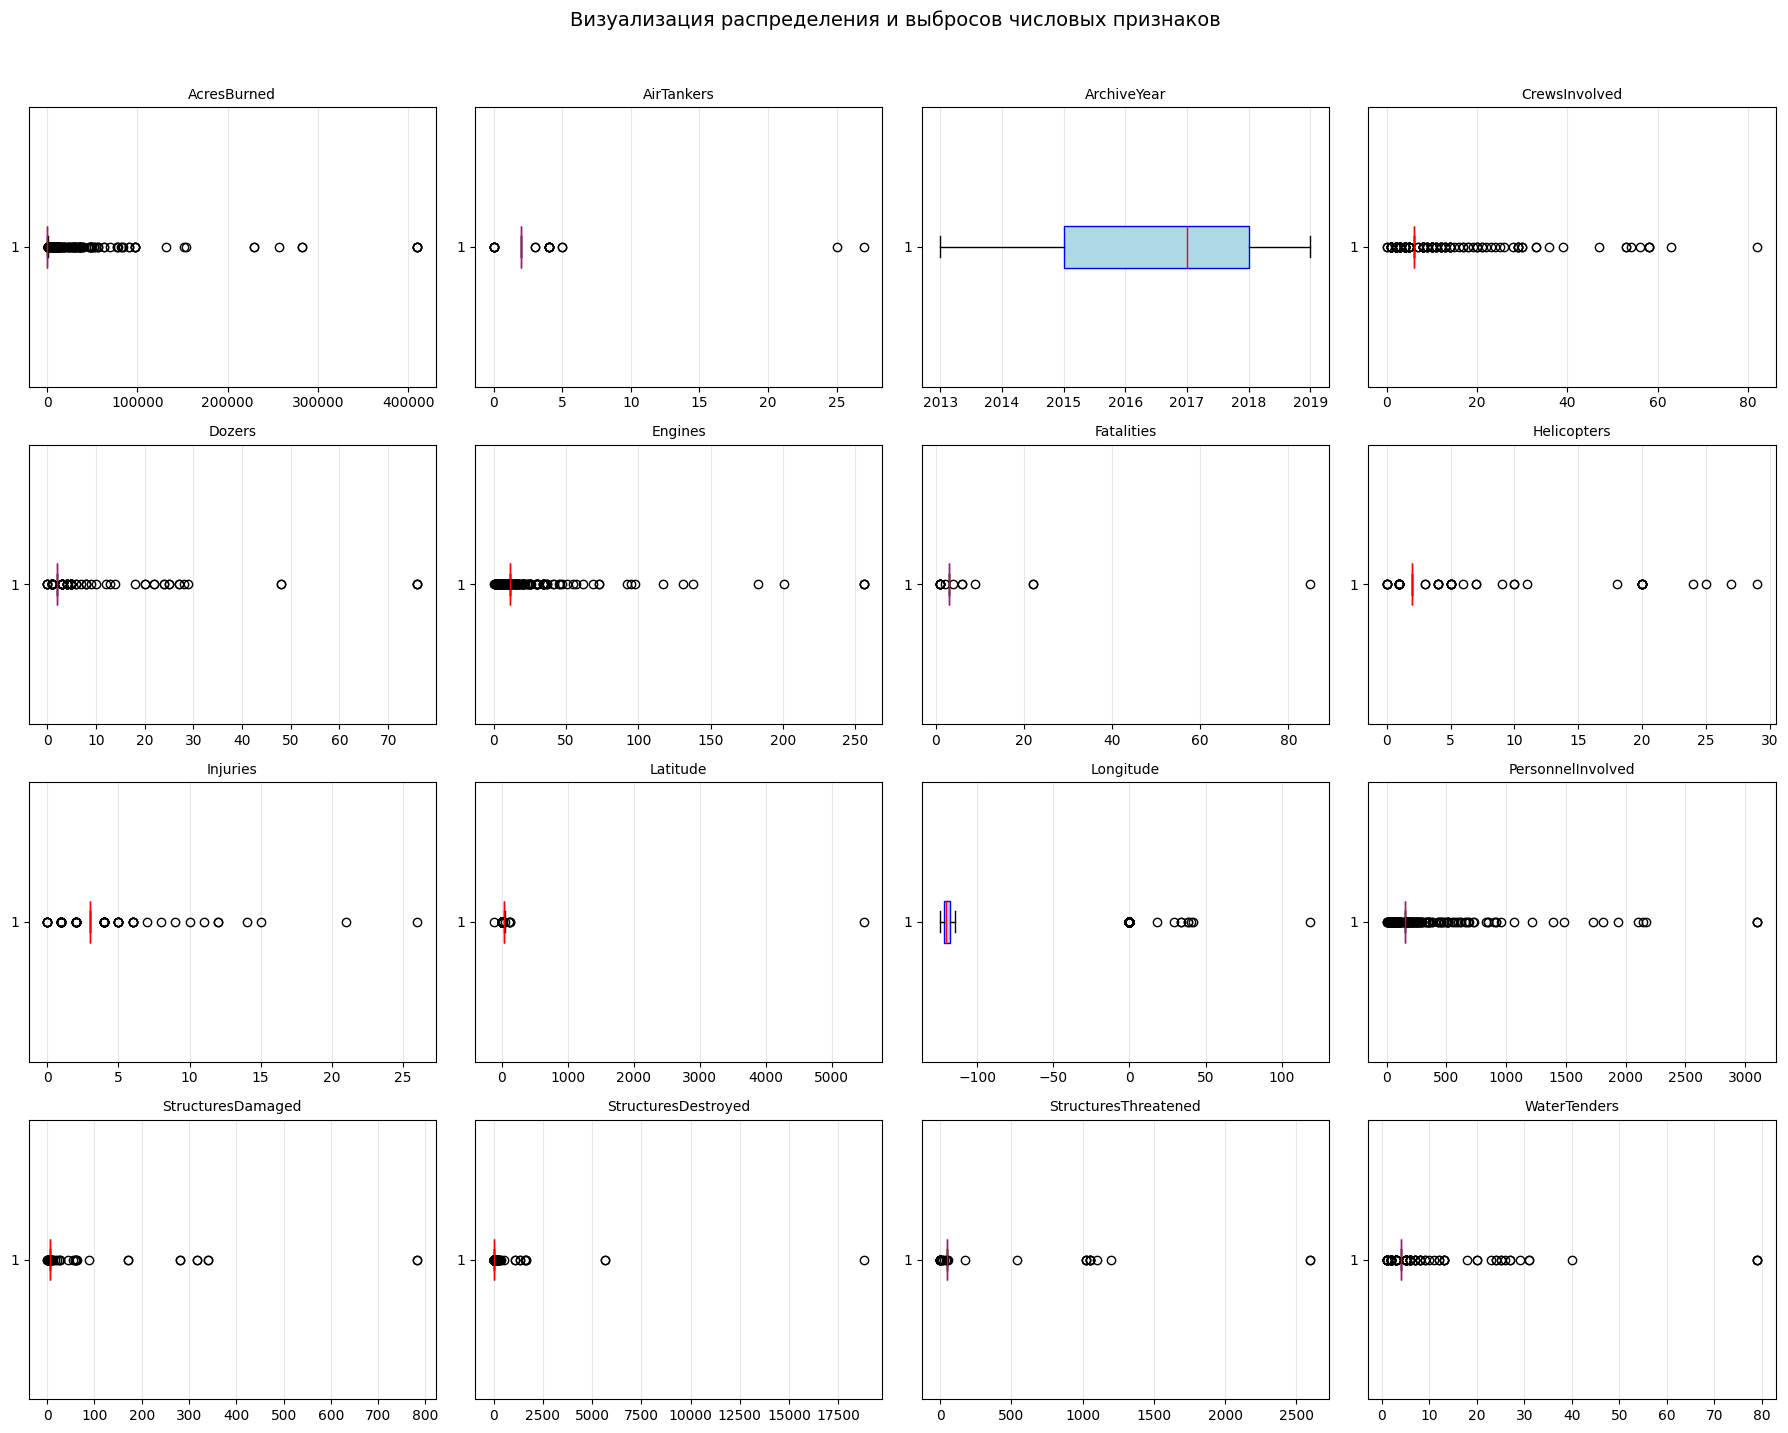

Построено графиков: 16


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Отбираем только числовые столбцы с достаточной вариацией
cols_to_plot = [col for col in numeric_df.columns
                if numeric_df[col].nunique() >= 2 and numeric_df[col].std() > 0]

n = len(cols_to_plot)
cols_per_row = 4
rows = int(np.ceil(n / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    data = numeric_df[col].dropna()

    # Простой boxplot через matplotlib
    ax.boxplot(data, vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='blue'),
               medianprops=dict(color='red'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'))

    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.grid(True, axis='x', alpha=0.3)

# Удаляем пустые подграфики
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Визуализация распределения и выбросов числовых признаков', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Построено графиков: {n}")

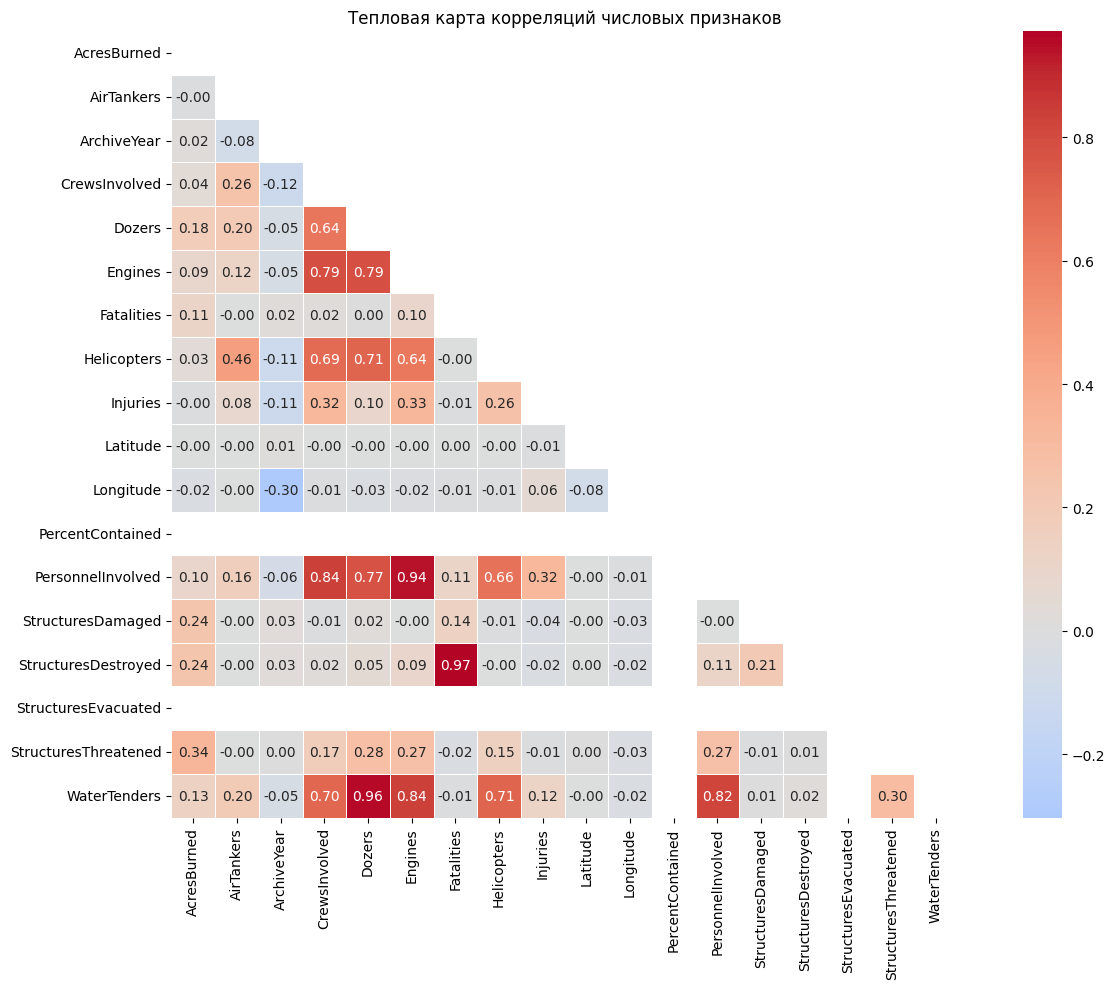

In [ ]:
import seaborn as sns
plt.figure(figsize=(14, 10))
corr_matrix = numeric_df.corr()
# Маска для отображения только нижней треугольной части
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций числовых признаков')
plt.tight_layout()
plt.show()

14.РСА

In [ ]:
# Берём только числовые признаки
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Удаляем столбцы, где ВСЕ значения NaN
numeric_df = numeric_df.dropna(axis=1, how='all')

# Заполняем оставшиеся пропуски медианой
numeric_df = numeric_df.fillna(numeric_df.median())
# Проверяем, остались ли NaN
print(numeric_df.isnull().sum().sum())
# Нормализация
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
# PCA
pca = PCA()
pca.fit(scaled_data)
# Накопленная дисперсия
explained_variance = pca.explained_variance_ratio_.cumsum()

# Количество компонент для 90%
components_90 = (explained_variance >= 0.90).argmax() + 1
print("Количество компонент:", components_90)

0
Количество компонент: 9


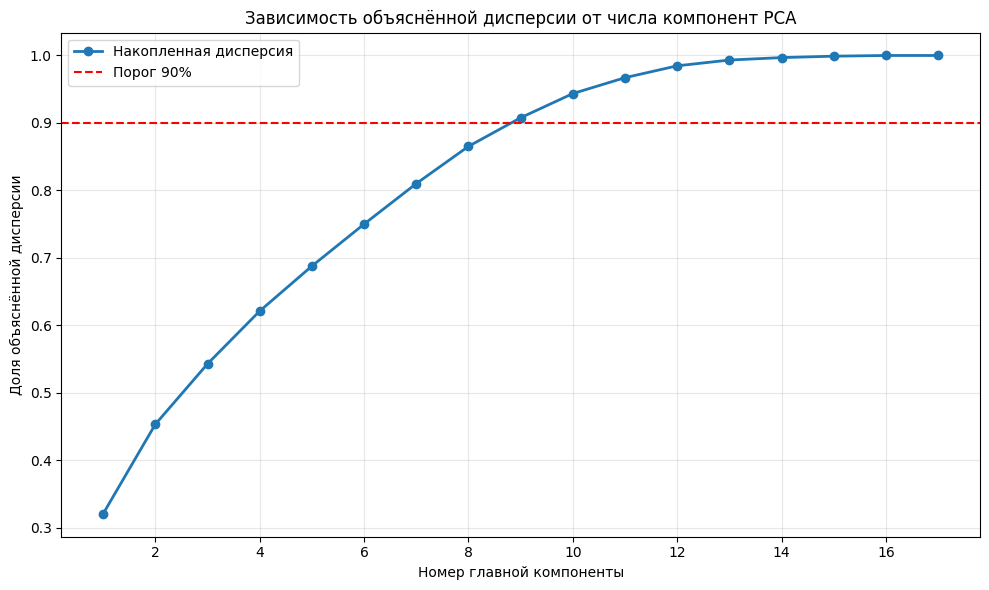

In [ ]:
# Индивидуальная и накопленная объяснённая дисперсия
individual_var = pca.explained_variance_ratio_
cumulative_var = individual_var.cumsum()
# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', linewidth=2, label='Накопленная дисперсия')
plt.axhline(y=0.90, color='red', linestyle='--', label='Порог 90%')
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Зависимость объяснённой дисперсии от числа компонент PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Из графика видно, что для достижения 90% объяснённой дисперсии достаточно 9 главных компонент. Первая компонента объясняет наибольшую долю вариативности данных, последующие компоненты вносят постепенно убывающий вклад. Такой характер кривой подтверждает целесообразность снижения размерности: исходные 18 числовых признаков могут быть заменены 9 ортогональными компонентами без существенной потери информации.

Для PCA используются только числовые признаки, поэтому идентификаторы и текстовые признаки автоматически исключаются из анализа.
Перед PCA были удалены признаки, полностью состоящие из пропусков, а оставшиеся пропуски заполнены медианными значениями.

Для объяснения 90% дисперсии оказалось достаточно 9 компонент.
Это означает, что большая часть информации датасета может быть представлена меньшим количеством признаков.

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


15. наибольший вклад в первую компоненту

In [ ]:
pca = PCA()
pca.fit(scaled_data)

# Коэффициенты первой компоненты
pc1 = pca.components_[0]

# Создаём таблицу вкладов
feature_importance = pd.DataFrame({
    'Feature': numeric_df.columns,
    'Contribution': np.abs(pc1)
})

# Сортировка
feature_importance = feature_importance.sort_values(by='Contribution',ascending=False)

print("Вклад признаков в первую компоненту")
print(feature_importance)
# Признак с максимальным вкладом
top_feature = feature_importance.iloc[0]

print("\nНаибольший вклад:")
print(top_feature)

Вклад признаков в первую компоненту
                 Feature  Contribution
12     PersonnelInvolved  4.118395e-01
5                Engines  4.082441e-01
16          WaterTenders  4.068740e-01
4                 Dozers  3.945790e-01
3          CrewsInvolved  3.802543e-01
7            Helicopters  3.605151e-01
15  StructuresThreatened  1.434865e-01
8               Injuries  1.411095e-01
1             AirTankers  1.339190e-01
0            AcresBurned  6.962507e-02
2            ArchiveYear  4.601541e-02
14   StructuresDestroyed  3.884455e-02
6             Fatalities  3.098709e-02
10             Longitude  5.158184e-03
13     StructuresDamaged  4.950163e-03
9               Latitude  1.266031e-03
11      PercentContained  5.169879e-26

Наибольший вклад:
Feature         PersonnelInvolved
Contribution              0.41184
Name: 12, dtype: object


Наибольший вклад в первую главную компоненту вносит признак PersonnelInvolved.
Это означает, что количество персонала является одним из наиболее значимых факторов изменчивости данных.

16. двухмерное представление с помощью алгоритма t-SNE

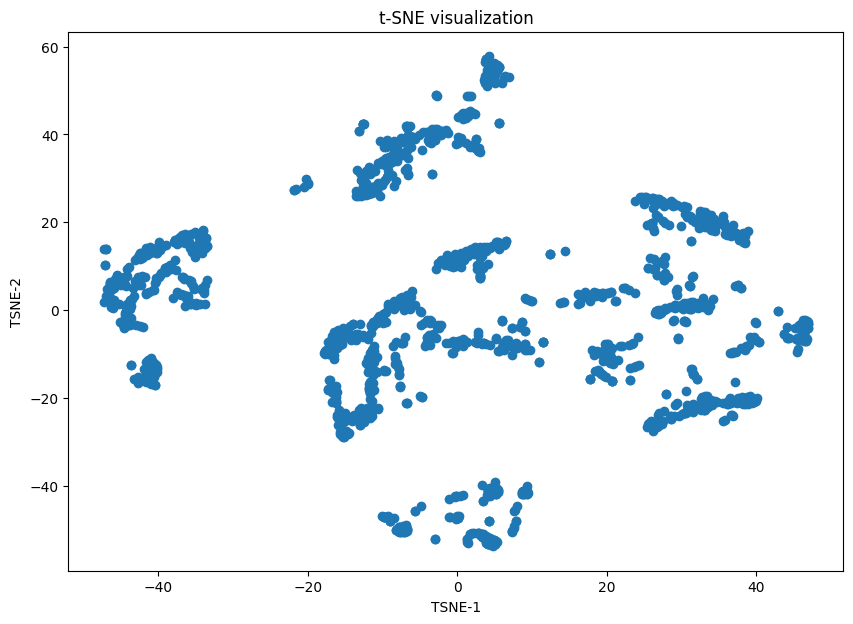

In [ ]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_result = tsne.fit_transform(scaled_data)

# DataFrame для визуализации

tsne_df = pd.DataFrame({
    'TSNE1': tsne_result[:, 0],
    'TSNE2': tsne_result[:, 1]
})
# График
plt.figure(figsize=(10, 7))
plt.scatter(
    tsne_df['TSNE1'],
    tsne_df['TSNE2']

)

plt.title('t-SNE visualization')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()

после применения алогритма t-SNE вузиально данные разделились на 4 кластера,
Вероятно, кластеры соответствуют:

-небольшие пожары с малым количеством техники и персонала;
-средние пожары;
-крупные пожары с большим количеством задействованных ресурсов и высокой площадью возгорания;
-отдельные аномальные пожары с экстремальными значениями.

Полного чёткого разделения не наблюдается, так как характеристики пожаров частично пересекаются и В датасете отсутствуют строго разделённые классы объектов, поэтому между группами присутствуют переходные значения

Вывод:

В ходе выполнения задания был проведён исследовательский анализ датасета California Fire Incidents, содержащего информацию о лесных пожарах в Калифорнии. Были определены типы признаков, выделены категориальные, бинарные и числовые параметры, а также проанализированы пропущенные значения.

Анализ показал наличие большого количества пропусков, причём некоторые признаки практически полностью состоят из отсутствующих значений. Также в данных были обнаружены выбросы, что характерно для информации о природных пожарах, поскольку отдельные инциденты значительно превосходят остальные по масштабу.

С помощью корреляционного анализа были выявлены сильные линейные зависимости между количеством персонала, техники и последствиями пожаров. Это подтверждает логичность структуры данных и наличие взаимосвязей между признаками.

После применения метода PCA было установлено, что для объяснения 90% дисперсии достаточно 9 главных компонент, что также подверждается графически , это позволяет существенно уменьшить размерность данных без значительной потери информации. Наибольший вклад в первую компоненту внёс признак PersonnelInvolved.

Дополнительно была выполнена визуализация данных с помощью алгоритма t-SNE. Визуально данные разделяются на несколько групп, соответствующих пожарам различного масштаба и уровня последствий.

В целом датасет содержит информативные признаки и подходит для дальнейшего анализа, построения моделей машинного обучения и прогнозирования характеристик пожаров.